## 10. Training Diagnostics

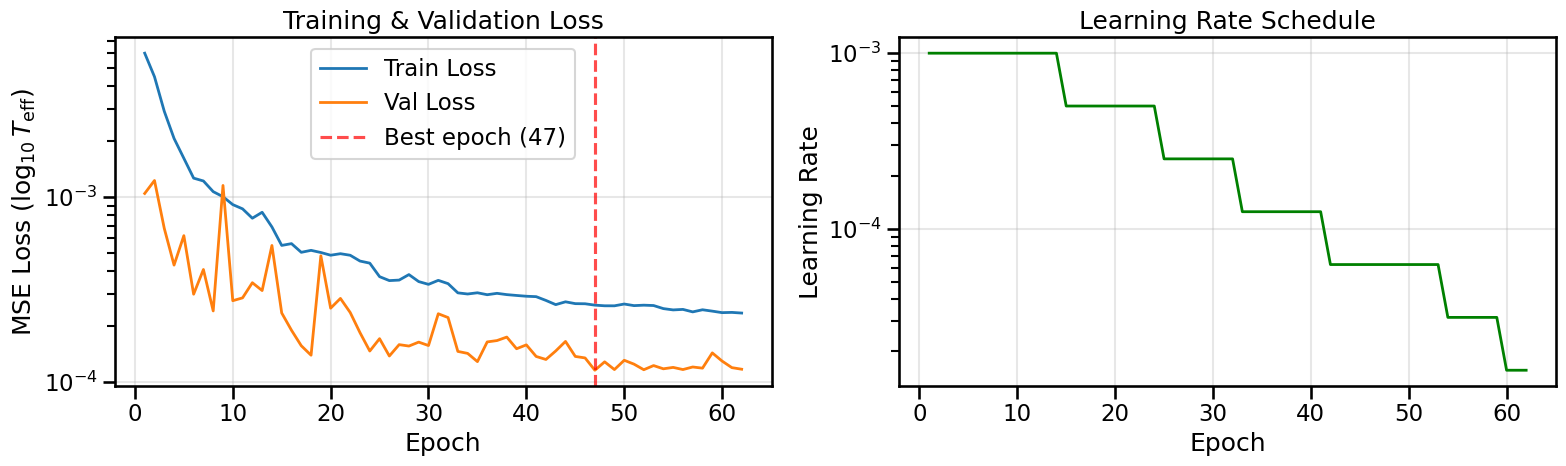

Saved: results/training_diagnostics.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Loss curves ---
ax = axes[0]
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label="Train Loss", linewidth=2)
ax.plot(epochs_range, val_losses, label="Val Loss", linewidth=2)
ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.7,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"MSE Loss ($\log_{10} T_{\mathrm{eff}}$)")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

# --- Learning rate schedule ---
ax = axes[1]
ax.plot(epochs_range, lr_history, linewidth=2, color="green")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: results/training_diagnostics.png")

## 11. Test Set Evaluation (Final Exam — Run Once)

Convert predictions from $\log_{10}(T)$ back to Kelvin before reporting metrics.

In [ ]:
# --- Predict on test set ---
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.numpy())

y_pred_log = np.concatenate(all_preds).flatten()    # log10(Teff) predicted
y_true_log = np.concatenate(all_targets).flatten()   # log10(Teff) true

# Convert back to Kelvin
y_pred_K = 10 ** y_pred_log
y_true_K = 10 ** y_true_log

# --- Compute metrics in Kelvin ---
rmse_K = np.sqrt(mean_squared_error(y_true_K, y_pred_K))
mae_K = mean_absolute_error(y_true_K, y_pred_K)
r2 = r2_score(y_true_K, y_pred_K)
median_ae_K = np.median(np.abs(y_pred_K - y_true_K))

# Also compute metrics in log10 space
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
mae_log = mean_absolute_error(y_true_log, y_pred_log)

print("=" * 50)
print("       TEST SET EVALUATION RESULTS")
print("=" * 50)
print(f"\n  In Kelvin:")
print(f"    RMSE:             {rmse_K:>8.1f} K")
print(f"    MAE:              {mae_K:>8.1f} K")
print(f"    Median AE:        {median_ae_K:>8.1f} K")
print(f"    R\u00b2:               {r2:>8.5f}")
print(f"\n  In log10(Teff):")
print(f"    RMSE:             {rmse_log:>8.6f}")
print(f"    MAE:              {mae_log:>8.6f}")

# --- Per spectral type metrics ---
print(f"\n{'_' * 50}")
print(f"  Per-Spectral-Type Breakdown (Kelvin)")
print(f"{'_' * 50}")
print(f"  {'Type':<6} {'N':>8} {'RMSE':>8} {'MAE':>8} {'MedAE':>8} {'R2':>8}")
print(f"  {'----':<6} {'----':>8} {'----':>8} {'----':>8} {'-----':>8} {'--':>8}")

for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    if mask.sum() == 0:
        continue
    yt = y_true_K[mask]
    yp = y_pred_K[mask]
    st_rmse = np.sqrt(mean_squared_error(yt, yp))
    st_mae = mean_absolute_error(yt, yp)
    st_medae = np.median(np.abs(yp - yt))
    st_r2 = r2_score(yt, yp)
    print(f"  {stype:<6} {mask.sum():>8,} {st_rmse:>8.1f} {st_mae:>8.1f} {st_medae:>8.1f} {st_r2:>8.4f}")

       TEST SET EVALUATION RESULTS

  In Kelvin:
    RMSE:                141.8 K
    MAE:                 104.0 K
    Median AE:            78.9 K
    R²:                0.96814

  In log10(Teff):
    RMSE:             0.010760
    MAE:              0.008081

__________________________________________________
  Per-Spectral-Type Breakdown (Kelvin)
__________________________________________________
  Type          N     RMSE      MAE    MedAE       R2
  ----       ----     ----     ----    -----       --
  F        46,246    171.4    127.1     97.8   0.8633
  G        95,550    129.7     96.4     74.7   0.9474
  K         4,862    112.2     84.4     65.8   0.9008
  M         5,290     73.4     57.0     44.9   0.8538


: 

## 12. Visualization — One-to-One Plot (Predicted vs True Teff)

A tight 45° line indicates accurate predictions. Watch for S-curve bias (regression to the mean).

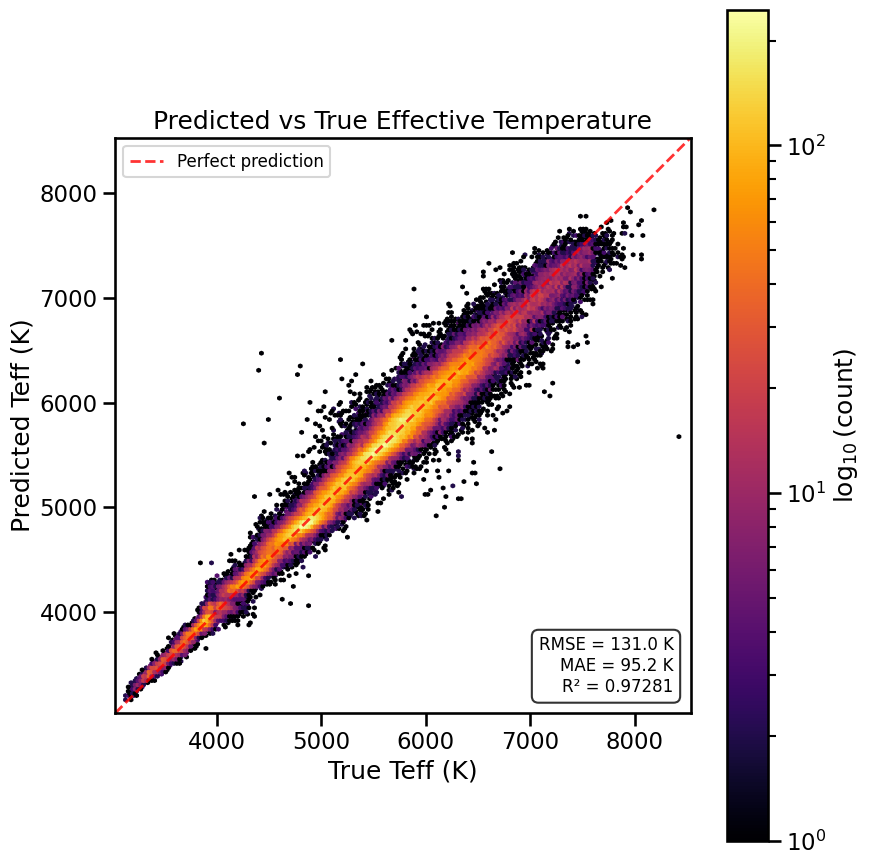

Saved: results/one_to_one_plot.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

# Hexbin for density visualization (too many points for scatter)
hb = ax.hexbin(y_true_K, y_pred_K, gridsize=200, cmap="inferno", mincnt=1, bins="log")
cb = plt.colorbar(hb, ax=ax, label=r"$\log_{10}$(count)")

# Perfect prediction line
lims = [min(y_true_K.min(), y_pred_K.min()) - 100,
        max(y_true_K.max(), y_pred_K.max()) + 100]
ax.plot(lims, lims, "r--", linewidth=2, alpha=0.8, label="Perfect prediction")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True Teff (K)")
ax.set_ylabel("Predicted Teff (K)")
ax.set_title("Predicted vs True Effective Temperature")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=12)

# Annotate metrics
textstr = f"RMSE = {rmse_K:.1f} K\nMAE = {mae_K:.1f} K\nR\u00b2 = {r2:.5f}"
ax.text(0.97, 0.03, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "one_to_one_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: results/one_to_one_plot.png")

## 13. Visualization — Residual Plot (The Debugger)

Residuals should be centered on 0 with no systematic structure. A smiley-face/S-curve shape indicates the model missed a pattern.

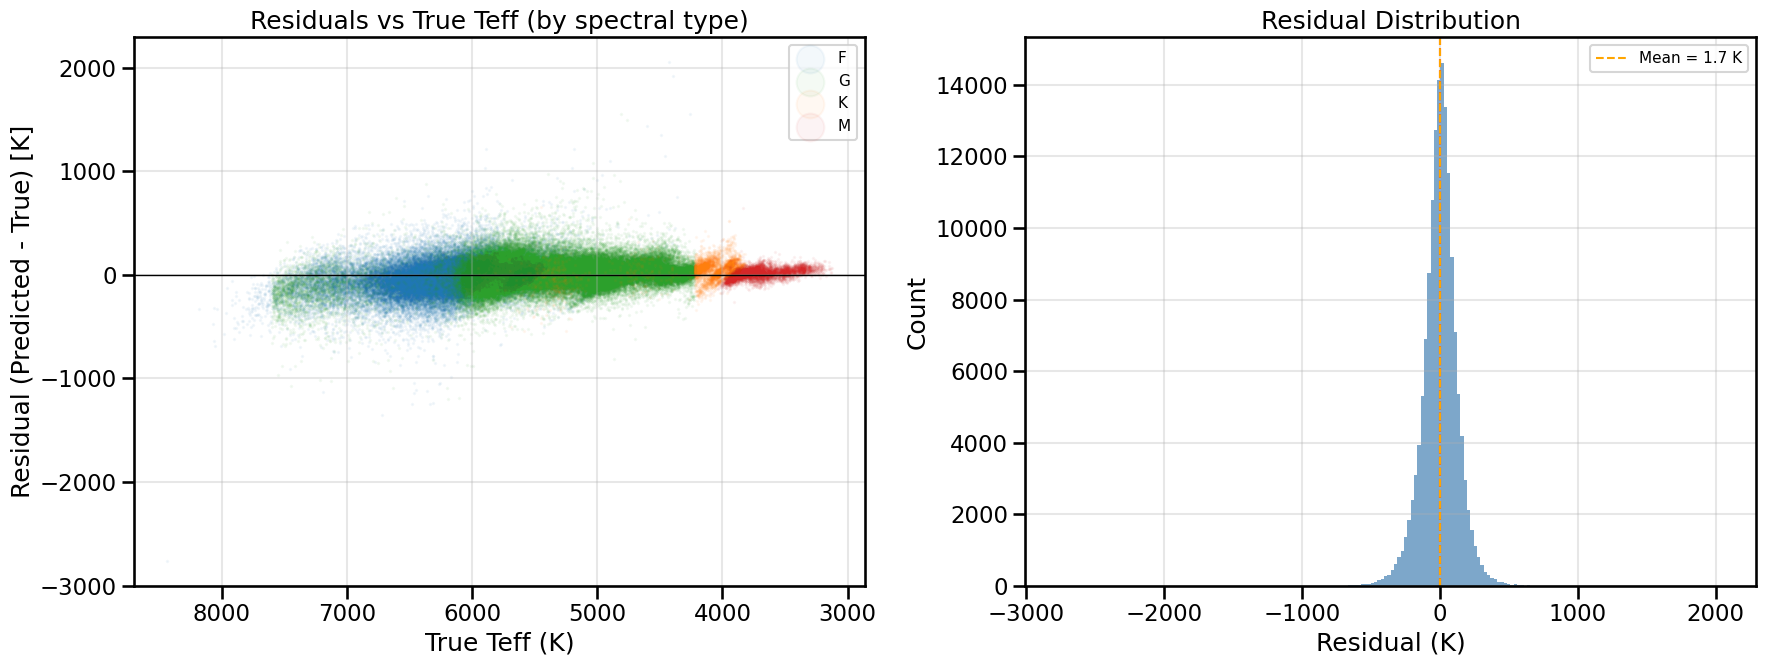

Saved: results/residual_plot.png


In [18]:
residuals_K = y_pred_K - y_true_K

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel A: Residuals vs True Teff, colored by spectral type ---
ax = axes[0]
colors_map = {"F": "#1f77b4", "G": "#2ca02c", "K": "#ff7f0e", "M": "#d62728"}
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    ax.scatter(y_true_K[mask], residuals_K[mask], alpha=0.05, s=1,
               color=colors_map[stype], label=stype, rasterized=True)
ax.axhline(0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("True Teff (K)")
ax.set_ylabel("Residual (Predicted - True) [K]")
ax.set_title("Residuals vs True Teff (by spectral type)")
ax.legend(markerscale=20, fontsize=11)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

# --- Panel B: Residual histogram ---
ax = axes[1]
ax.hist(residuals_K, bins=200, edgecolor="none", alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.axvline(np.mean(residuals_K), color="orange", linestyle="--", linewidth=1.5,
           label=f"Mean = {np.mean(residuals_K):.1f} K")
ax.set_xlabel("Residual (K)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "residual_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: results/residual_plot.png")

## 14. Visualization — HR Diagram (Physics Sanity Check)

Side-by-side HR diagrams colored by **true** vs **predicted** Teff. The color gradient should look smooth and physically consistent — cool M-dwarfs (red) in the bottom-right, hot F-dwarfs (blue) in the upper-left.

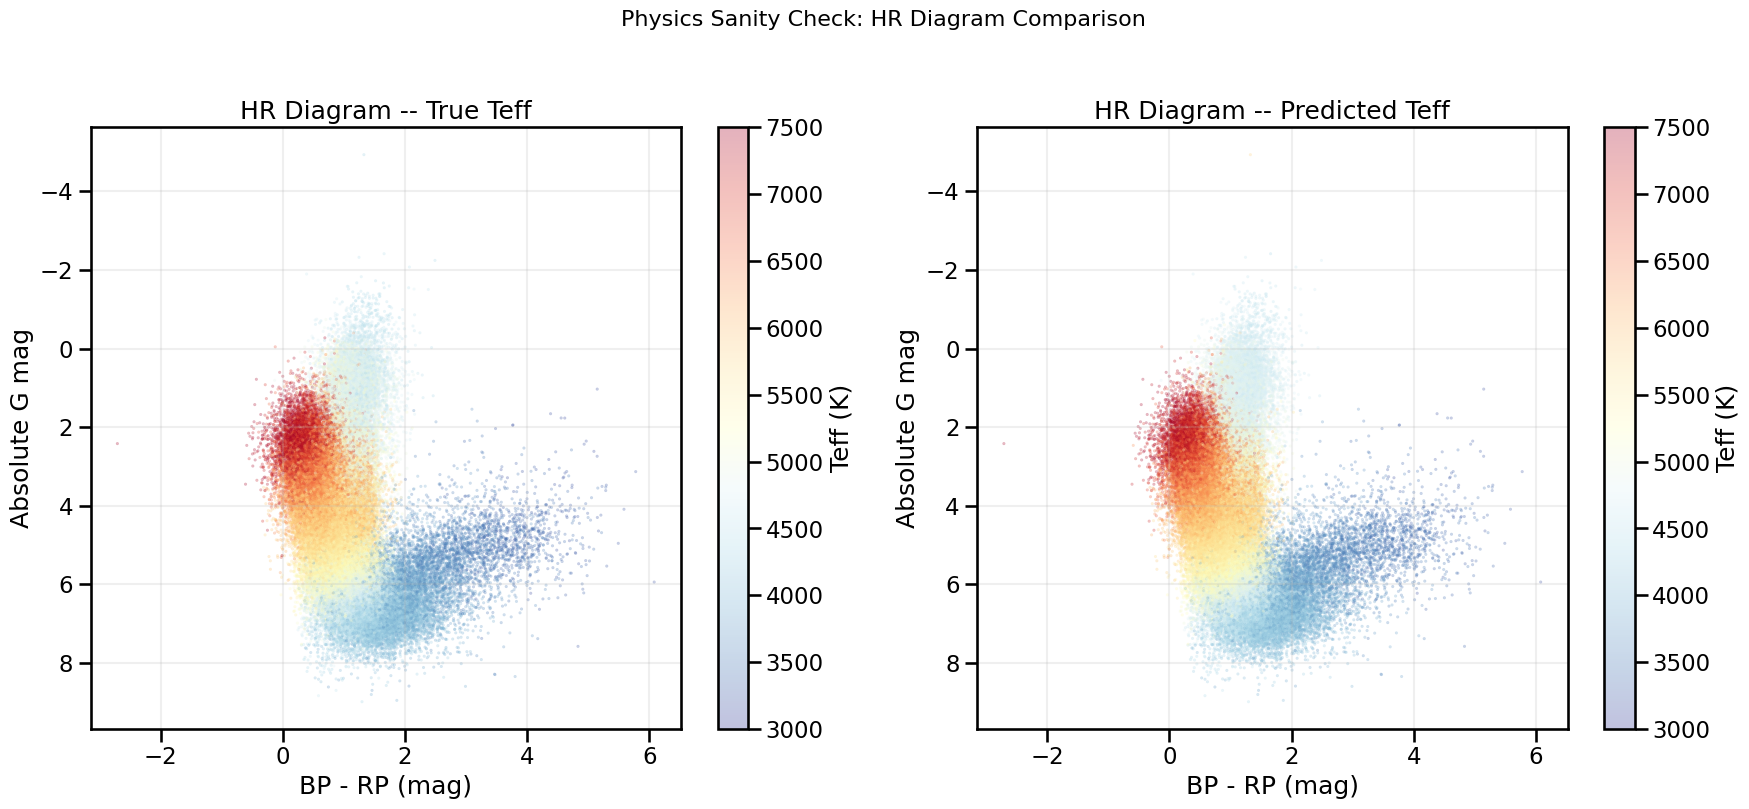

Saved: results/hr_diagram_comparison.png


In [20]:
# Retrieve unscaled COLOR_GAIA_BP_RP and A_GG from the test set
bp_rp_idx = FEATURE_COLS.index("COLOR_GAIA_BP_RP")
agg_idx = FEATURE_COLS.index("A_GG")

test_bp_rp = X_test[:, bp_rp_idx]   # original (unscaled) values
test_agg = X_test[:, agg_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Panel A: HR diagram colored by TRUE Teff ---
ax = axes[0]
sc1 = ax.scatter(test_bp_rp, test_agg, c=y_true_K, cmap="RdYlBu_r",
                 s=0.5, alpha=0.3, vmin=3000, vmax=7500, rasterized=True)
ax.set_xlabel("BP - RP (mag)")
ax.set_ylabel("Absolute G mag")
ax.set_title("HR Diagram -- True Teff")
ax.invert_yaxis()
plt.colorbar(sc1, ax=ax, label="Teff (K)")
ax.grid(True, alpha=0.2)

# --- Panel B: HR diagram colored by PREDICTED Teff ---
ax = axes[1]
sc2 = ax.scatter(test_bp_rp, test_agg, c=y_pred_K, cmap="RdYlBu_r",
                 s=0.5, alpha=0.3, vmin=3000, vmax=7500, rasterized=True)
ax.set_xlabel("BP - RP (mag)")
ax.set_ylabel("Absolute G mag")
ax.set_title("HR Diagram -- Predicted Teff")
ax.invert_yaxis()
plt.colorbar(sc2, ax=ax, label="Teff (K)")
ax.grid(True, alpha=0.2)

plt.suptitle("Physics Sanity Check: HR Diagram Comparison", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "hr_diagram_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: results/hr_diagram_comparison.png")

## 15. Save Model & Results

In [21]:
# --- Save best model state dict ---
model_save_path = MODELS_DIR / "stellar_teff_ann_best.pth"
torch.save({
    "model_state_dict": best_model_state,
    "input_dim": len(FEATURE_COLS),
    "feature_cols": FEATURE_COLS,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "architecture": str(model),
}, model_save_path)
print(f"Model saved to {model_save_path}")

# --- Save scaler ---
scaler_save_path = MODELS_DIR / "scaler.pkl"
joblib.dump(scaler, scaler_save_path)
print(f"Scaler saved to {scaler_save_path}")

# --- Save test metrics ---
metrics = {
    "rmse_kelvin": round(float(rmse_K), 2),
    "mae_kelvin": round(float(mae_K), 2),
    "median_ae_kelvin": round(float(median_ae_K), 2),
    "r2_score": round(float(r2), 6),
    "rmse_log10": round(float(rmse_log), 6),
    "mae_log10": round(float(mae_log), 6),
    "best_epoch": best_epoch,
    "total_epochs_run": len(train_losses),
    "n_train": len(y_train),
    "n_val": len(y_val),
    "n_test": len(y_test),
    "n_features": len(FEATURE_COLS),
}
metrics_path = RESULTS_DIR / "test_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to {metrics_path}")

print(f"\n{'=' * 50}")
print(f"  All artifacts saved successfully!")
print(f"{'=' * 50}")

Model saved to C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\stellar_teff_ann_best.pth
Scaler saved to C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\scaler.pkl
Metrics saved to C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\test_metrics.json

  All artifacts saved successfully!
